In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import integrate
from pathlib import Path

In [2]:
DATASET_PATH = Path() / "dataset"

# Zadanie 1

Wykonaj aproksymację średniokwadratową **punktową** populacji Stanów Zjednoczonych w przedziale $[1900,1980]$ wielomianami stopnia $m$ dla $0 \le m \le 6$.

In [3]:
df_population = pd.read_csv(DATASET_PATH / r"population.dat", header=0, dtype={"year": np.int64, "population": np.int64})
df_population  # df_population.loc[df_population["year"] <= 1980]

,year,population
0,1900,76212168
1,1910,92228496
2,1920,106021537
3,1930,123202624
4,1940,132164569
5,1950,151325798
6,1960,179323175
7,1970,203302031
8,1980,226542199
9,1990,248709873


In [4]:
np_population = df_population.loc[df_population["year"] <= 1980].values
years = np_population[:, 0].astype(np.float64)
population = np_population[:, 1].astype(np.float64)
approx_years = np.arange(1900, 1991, 1)
population_1990 = df_population.loc[df_population["year"] == 1990].values[0, 1]

In [5]:
def AIC_c(poly_d: int, y: np.array, y_hat: np.array):
    n = y.size
    k = poly_d + 1
    RSS = np.sum((y - y_hat) ** 2)
    AIC = 2 * k + n * np.log(RSS / n) + 2 * k * (k + 1) / (n - k - 1)
    return AIC

In [6]:
poly_d_np_approx_population = {}
approx_population_1990 = {
    "degree": [],
    "population_1990": [],
    "AIC_c": [],
    "relative_error": [],
}

for poly_d in range(0, 7):
    A = np.vander(years, poly_d + 1, True)
    solution, _, _, _ = np.linalg.lstsq(A, population, rcond=None)
    solution = solution[::-1]
    approx_population = np.polyval(solution, approx_years)
    np_approx_population = np.stack((approx_years, approx_population), axis=-1)
    aic_c = AIC_c(poly_d, population, np.polyval(solution, years))
    approx_1990 = np.polyval(solution, 1990)

    poly_d_np_approx_population[poly_d] = np_approx_population
    approx_population_1990["degree"].append(poly_d)
    approx_population_1990["population_1990"].append(approx_1990)
    approx_population_1990["AIC_c"].append(aic_c)
    approx_population_1990["relative_error"].append(
        100 * np.abs((approx_1990 - population_1990) / population_1990)
    )

df_approx_population_1990 = pd.DataFrame(approx_population_1990)

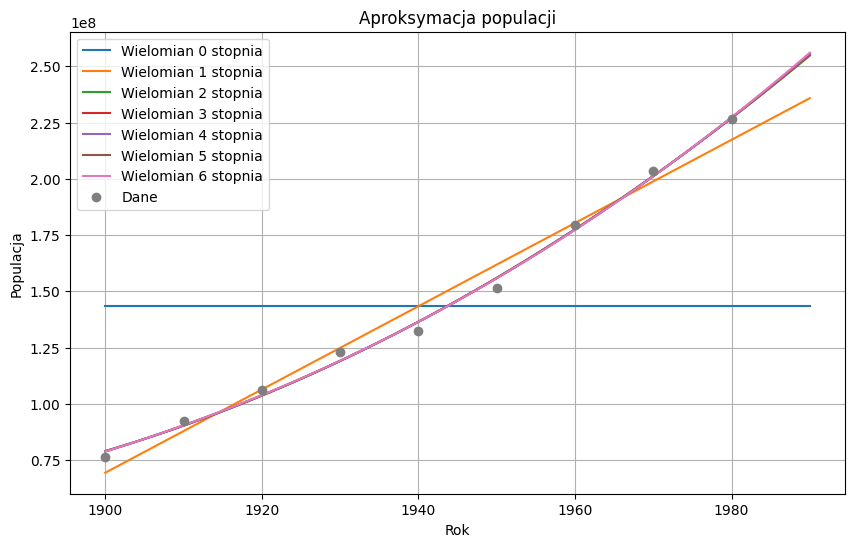

In [7]:
plt.figure(figsize=(10, 6))
for poly_d, np_approx_population in poly_d_np_approx_population.items():
    plt.plot(np_approx_population[:, 0], np_approx_population[:, 1], label=f"Wielomian {poly_d} stopnia")
plt.plot(years, population, "o", label="Dane")
plt.xlabel("Rok")
plt.ylabel("Populacja")
plt.title("Aproksymacja populacji")
plt.grid(True)
plt.legend()
plt.show()

### a)

Dla każdego m dokonaj ekstrapolacji wielomianu do roku 1990. Porównaj otrzymaną wartość z prawdziwą wartością dla roku 1990, wynoszącą $248 709 873$. Ile wynosi błąd względny ekstrapolacji dla roku 1990? Dla jakiego m błąd względny był najmniejszy?

In [8]:
df_approx_population_1990.style.hide(axis="index").format(
    {
        "population_1990": "{:.0f}",
        "AIC_c": "{:.2f}",
        "relative_error": "{:.2f}%",
    }
)

degree,population_1990,AIC_c,relative_error
0,143369177,321.01,42.35%
1,235808109,289.06,5.19%
2,254712945,279.45,2.41%
3,255075617,286.50,2.56%
4,255410617,298.37,2.69%
5,255718652,322.26,2.82%
6,256000451,394.16,2.93%


### b)

Zbyt niski stopień wielomianu oznacza, że model nie jest w stanie uwzględnić zmienności danych (duże obciążenie). Zbyt wysoki stopień wielomianu oznacza z kolei, że model uwzględnia szum lub błędy danych (duża wariancja), co w szczególności obserwowaliśmy w przypadku interpolacji. Wielomian stopnia $m$ posiada $k = m + 1$ parameterów. Stopień wielomianu, $m$, jest hiperparametrem modelu. Do wyboru optymalnego stopnia wielomianu można posłużyć się kryterium informacyjnym Akaikego (ang. Akaike information criterion):
$$ \text{AIC} = 2k + n \ln \left( \frac{\sum_{i=1}^{n} [y_i - \hat{y}(x_i)]^2}{n} \right) \ , $$
gdzie $y_i \ (i = 1, ..., n)$ oznacza prawdziwą liczbę osób w roku $x_i$, natomiast $\hat{y}(x_i)$ liczbę osób przewidywaną przez ten model, tzn wartość wielomianu $\hat{y}(x)$.

Ponieważ rozmiar próbki jest niewielki (dane z dziewięciu lat, $n = 9$), $n/k < 40$, należy użyć wzoru ze składnikiem korygującym:
$$ \text{AIC}_\text{c} = \text{AIC} + \frac{2k(k+1)}{n - k - 1} \ . $$
Mniejsze wartości kryterium oznaczają lepszy model. Czy wyznaczony w ten sposób stopień $m$, odpowiadający najmniejszej wartości $\text{AIC}_\text{c}$, pokrywa się z wartością z poprzedniego podpunktu?

# Zadanie 2

Wykonaj aproksymację średniokwadratową **ciągłą** funkcji $f(x) = \sqrt{x}$ w przedziale $[0,2]$ wielomianem drugiego stopnia, używając wielomianów Czebyszewa. Aproksymacja ta jest tańszym obliczeniowo zamiennikiem aproksymacji jednostajnej.

In [46]:
def f(x):
    return np.sqrt(x)


def t(x):
    # transform from [-1, 1] to [0, 2]
    # using: a + (b - a) * (r + 1) / 2
    return x - 1

def chebyshev_weight_f(t):
    return (1 - (t**2)) ** (-1 / 2)


def T(k, x):
    return np.cos(k * np.arccos(x))

In [47]:
number_of_chebyschev_poly = 2
coefficients = []
for k in range(number_of_chebyschev_poly):
    T_mul_T = np.pi if k == 0 else np.pi / 2
    c = (
        integrate.quad(lambda x: chebyshev_weight_f(t(x)) * f(x) * T(k, t(x)), 0, 2)[0]
        / T_mul_T
    )
    coefficients.append(c)

In [48]:
def approx_f(x, coefficients):
    result = 0
    for k, c in enumerate(coefficients):
        result += c * T(k, t(x))
    return result

6.785567658440517e-05


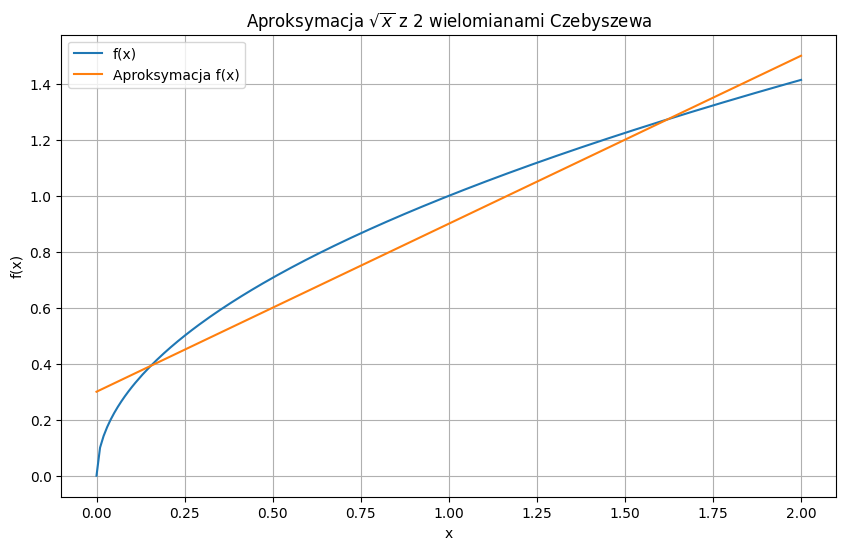

In [49]:
xs = np.linspace(0, 2, 200)
ys = f(xs)
ys_approx = approx_f(xs, coefficients)
plt.figure(figsize=(10, 6))
plt.plot(xs, ys, label="f(x)")
plt.plot(xs, ys_approx, label="Aproksymacja f(x)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(f"Aproksymacja $\sqrt{{x}}$ z {number_of_chebyschev_poly} wielomianami Czebyszewa")
plt.grid(True)
plt.legend()
plt.show()